<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L2A_L2B_L1B_merged_11_3_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load .npy
L1B_data = np.load("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy", allow_pickle=True)
real_data = L1B_data.item()

# Convert dict to DataFrame
df = pd.DataFrame(real_data)

# Create GeoDataFrame using correct lat/lon keys
l1b = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude_bin0'], df['latitude_bin0']))
l1b.set_crs("EPSG:4326", inplace=True)  # WGS84


# Rename to match L2A + L2B field names
l1b = l1b.rename(columns={
    "latitude_bin0": "lat",
    "longitude_bin0": "lon"
})

# Add product field
l1b['product_field'] = 'GEDI_L1B'
# # Export to GeoPackage (better for large datasets)
# gdf.to_file("/content/GEDI_points.gpkg", layer='GEDI', driver="GPKG")

# # Optional: Export to Shapefile
# gdf.to_file("/content/GEDI_points.shp")


In [ ]:
l1b

,lat,lon,shot_number,degrade,stale_return_flag,elevation_bin0,rxwaveform,rx_energy,rx_sample_count,rx_sample_start_index,solar_elevation,digital_elevation_model,geometry,product_field
0,35.127069,-85.970562,24260500200098456,50,0,590.971583,"[202.47792, 202.89435, 203.66626, 204.3605, 20...","[20362.71875, 20192.75, 18956.15625, 20506.5, ...",964,1,-17.281101,531.902954,POINT (-85.97056 35.12707),GEDI_L1B
1,35.127418,-85.970101,24260500200098457,50,0,593.621272,"[202.69899, 203.42856, 204.38269, 205.28769, 2...",[],917,1421,-17.281185,502.885101,POINT (-85.9701 35.12742),GEDI_L1B
2,35.127768,-85.969637,24260500200098458,50,0,588.717999,"[205.0785, 204.71707, 204.06787, 203.38005, 20...",[],938,2841,-17.281269,502.885101,POINT (-85.96964 35.12777),GEDI_L1B
3,35.128117,-85.969175,24260500200098459,50,0,589.106671,"[201.8905, 201.79706, 202.21419, 202.93555, 20...",[],929,4261,-17.281353,473.641388,POINT (-85.96918 35.12812),GEDI_L1B
4,35.128469,-85.968712,24260500200098460,50,0,581.561383,"[203.24417, 202.97984, 203.04758, 203.2419, 20...",[],942,5681,-17.281437,449.055176,POINT (-85.96871 35.12847),GEDI_L1B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3841,35.145647,-85.858979,331701100300207190,0,0,619.756293,"[220.95575, 221.34393, 221.7683, 222.07947, 22...",[],950,364941,43.667702,556.715759,POINT (-85.85898 35.14565),GEDI_L1B
3842,35.145297,-85.858518,331701100300207191,0,0,618.901499,"[223.6161, 224.2495, 224.8175, 224.80887, 224....",[],946,366361,43.668106,548.169678,POINT (-85.85852 35.1453),GEDI_L1B
3843,35.144948,-85.858061,331701100300207192,0,0,611.594018,"[220.40059, 220.24179, 220.24332, 220.13715, 2...",[],894,367781,43.668510,548.169678,POINT (-85.85806 35.14495),GEDI_L1B
3844,35.144597,-85.857598,331701100300207193,0,0,614.310209,"[228.7051, 228.67126, 228.21051, 227.88002, 22...",[],919,369201,43.668919,552.613403,POINT (-85.8576 35.1446),GEDI_L1B


In [ ]:
import pandas as pd
import numpy as np

# L2B CSV
l2b_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/filtered_csvs/GEDI_filtered_merged.csv"
l2b = pd.read_csv(l2b_path)
l2b['product_field'] = 'GEDI_L2B'  # add the product field

# L2A CSV
l2a_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/L2A_filtered_csvs/GEDI_L2A_filtered_merged.csv"
l2a = pd.read_csv(l2a_path)
l2a['product_field'] = 'GEDI_L2A'  # add the product field


qqqqqqqqqqqqqqqqqqqqqqqqq

In [ ]:
# Align columns: add missing columns to each dataset if needed
all_cols = set(l2a.columns) | set(l2b.columns) | set(l1b.columns)

for df in [l2a, l2b, l1b]:
    missing = all_cols - set(df.columns)
    for col in missing:
        df[col] = np.nan  # fill missing columns with NaN

# Concatenate vertically
merged_all = pd.concat([l2a, l2b, l1b], ignore_index=True)


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

In [ ]:
print(merged_all.head())
print(merged_all['product_field'].value_counts())

# Save as CSV
merged_all.to_csv("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25.csv", index=False)


       beam                                        source_file        lat  \
0  BEAM0101  118699863_GEDI02_A_2020196021509_O08987_02_T05...  35.214071   
1  BEAM0101  118699863_GEDI02_A_2020196021509_O08987_02_T05...  35.214767   
2  BEAM0101  118699863_GEDI02_A_2020196021509_O08987_02_T05...  35.215471   
3  BEAM0101  118699863_GEDI02_A_2020196021509_O08987_02_T05...  35.215807   
4  BEAM0101  118699863_GEDI02_A_2020196021509_O08987_02_T05...  35.216501   

         lon  elev_lowestmode  digital_elevation_model  solar_elevation  \
0 -85.989695       455.898773               470.743774       -18.850618   
1 -85.988777       459.104523               467.231506       -18.850683   
2 -85.987846       449.121246               455.059265       -18.850748   
3 -85.987407       470.780426               477.108856       -18.850777   
4 -85.986494       478.569794               489.838898       -18.850840   

   sensitivity  degrade_flag  quality_flag  ...  count  pai_z_bin_22  \
0     0.977285

Make a Map

In [ ]:
# Install required packages
!pip install geopandas shapely contextily mapclassify

/tmp/ipython-input-3266792350.py:11: DtypeWarning:

Columns (0,1,90) have mixed types. Specify dtype option on import or set low_memory=False.



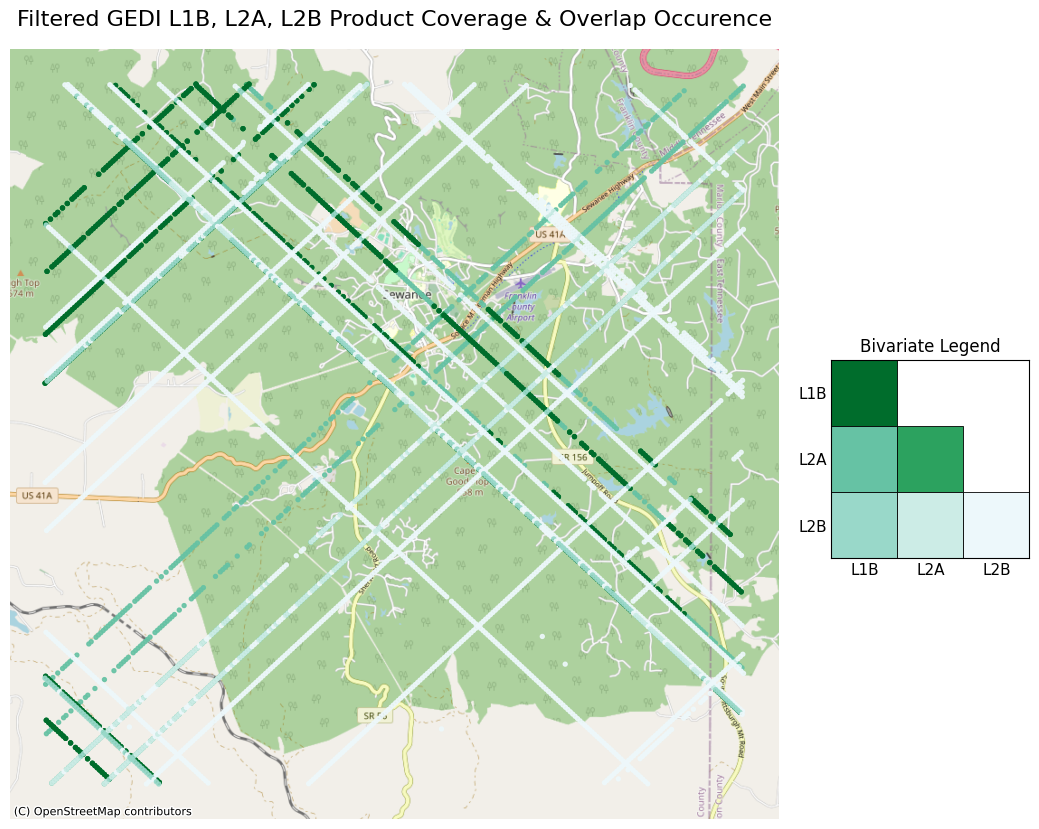


=== Summary of Observations by Category ===

                 count
group                 
single_GEDI_L1B   3025
single_GEDI_L2B   1771
single_GEDI_L2A    970
L2A-L2B            898
L1B-L2A            480
L1B-L2B            341

Total observations: 7485


In [23]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.patches import Rectangle

# ---------------------------------------------------
# Load Data
# ---------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25.csv")

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs=4326).to_crs(3857)

# ---------------------------------------------------
# Compute Overlaps (50 m)
# ---------------------------------------------------
def buf50(df):
    return df.assign(buf=df.geometry.buffer(25))

l1b = buf50(gdf[gdf.product_field=="GEDI_L1B"])
l2a = buf50(gdf[gdf.product_field=="GEDI_L2A"])
l2b = buf50(gdf[gdf.product_field=="GEDI_L2B"])

def overlap(a,b,label):
    hit = gpd.sjoin(a.set_geometry("buf"), b.set_geometry("buf"), predicate="intersects")
    return a.loc[hit.index.unique()].assign(group=label)

o_l1b_l2a = overlap(l1b, l2a, "L1B-L2A")
o_l1b_l2b = overlap(l1b, l2b, "L1B-L2B")
o_l2a_l2b = overlap(l2a, l2b, "L2A-L2B")

# Assign groups
gdf["group"] = "single_" + gdf.product_field
combined_overlaps = pd.concat([o_l1b_l2a, o_l1b_l2b, o_l2a_l2b])
gdf.loc[combined_overlaps.index, "group"] = combined_overlaps.group

# ---------------------------------------------------
# 6‐class palette (A–F)
# ---------------------------------------------------
palette = {
    "single_GEDI_L1B": "#edf8fb",  # A
    "L1B-L2A":         "#ccece6",  # B
    "L1B-L2B":         "#99d8c9",  # C
    "single_GEDI_L2A": "#66c2a4",  # D
    "L2A-L2B":         "#2ca25f",  # E
    "single_GEDI_L2B": "#006d2c"   # F
}

# ---------------------------------------------------
# Legend matrix rotated 180° (descending stairs)
# ---------------------------------------------------
# legend_matrix = [
#     [None,                None,                "single_GEDI_L2B"],   # L1B row
#     [None,                "L2A-L2B",           "single_GEDI_L2A"],   # L2A row
#     ["L1B-L2B",           "L1B-L2A",           "single_GEDI_L1B"]    # L2B row
# ]


legend_matrix = [
    ["single_GEDI_L2B", None, None],   # L1B row
    ["single_GEDI_L2A", "L2A-L2B",  None],   # L2A row
    ["L1B-L2B",  "L1B-L2A","single_GEDI_L1B"]    # L2B row
]

# ---------------------------------------------------
# Plot Map
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(11,10))

gdf.plot(ax=ax, markersize=8, color=gdf.group.map(palette), alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("Filtered GEDI L1B, L2A, L2B Product Coverage & Overlap Occurence", fontsize=16)

# ---------------------------------------------------
# Plot Legend (placed just outside the map)
# ---------------------------------------------------
leg_ax = fig.add_axes([0.91, 0.28, 0.18, 0.38])  # <- adjust this to move closer/farther

for r in range(3):
    for c in range(3):
        val = legend_matrix[r][c]
        if val is None:
            continue
        leg_ax.add_patch(Rectangle((c, r), 1, 1,
                                   facecolor=palette[val],
                                   edgecolor="black",
                                   linewidth=0.6))

leg_ax.set_xticks([0.5,1.5,2.5])
leg_ax.set_xticklabels(["L1B","L2A","L2B"], fontsize=11)

leg_ax.set_yticks([0.5,1.5,2.5])
leg_ax.set_yticklabels(["L1B","L2A","L2B"], fontsize=11)

leg_ax.set_xlim(0,3)
leg_ax.set_ylim(3,0)  # flip orientation
leg_ax.set_aspect("equal")
leg_ax.tick_params(length=0)
leg_ax.set_title("Bivariate Legend", fontsize=12)

plt.show()


# ---------------------------------------------------
# Summary Statistics
# ---------------------------------------------------
summary = gdf["group"].value_counts().rename("count")
print("\n=== Summary of Observations by Category ===\n")
print(summary.to_frame())
print("\nTotal observations:", len(gdf))



# ---------------------------------------------------
# Export ready for publication
# ---------------------------------------------------
fig.savefig("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_bivariate_map_published.png", dpi=600, bbox_inches='tight')
